# Streaming U-Net with lat/lon (spatial) chunking

Spatial-chunk version of `2-U_Net-Streaming_Version`. Instead of streaming 100-day whole-domain blocks,
this tiles the **full IO grid** into **40x56** patches that match the on-disk chunking of
`IO_rechunked.zarr` (the PACE-like `time=1` layout). One sample is one day of one 40x56 patch.

Structure:
1. Config (start small, then scale up).
2. Load the full grid and build the standardized channels aligned to the 40x56 chunks.
3. Same U-Net as the original.
4. Train on spatial patches via Eli's `make_xbatcher` helper (aligned, non-overlapping), batched patches.
5. Evaluate + graphs, same as the original.

**Next steps** (xbatcher features to adopt) are kept at the bottom. Start with `EPOCHS=3` to confirm it
trains, then raise it for the full run.

In [1]:
!pip install git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@troy-branch

  Cloning https://github.com/SAFS-Varanasi-Internship/mindthegap.git (to revision troy-branch) to /tmp/pip-req-build-h0tgzobj
  Running command git clone --filter=blob:none --quiet https://github.com/SAFS-Varanasi-Internship/mindthegap.git /tmp/pip-req-build-h0tgzobj
  Running command git checkout -b troy-branch --track origin/troy-branch
  Switched to a new branch 'troy-branch'
  branch 'troy-branch' set up to track 'origin/troy-branch'.
  Resolved https://github.com/SAFS-Varanasi-Internship/mindthegap.git to commit fabbf6836a14306fe0bcd9693ca4d2597300f347
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import calendar
import sys
sys.path.insert(0, os.path.abspath('.'))

os.environ.pop("TF_CUDNN_DETERMINISTIC", None)
os.environ.pop("TF_CUDNN_USE_AUTOTUNE", None)
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_CPP_VMODULE"] = "conv_algorithm_picker=0,cuda_timer=0"

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU ready:", tf.config.experimental.get_device_details(gpus[0]))
    except RuntimeError as e:
        print(f"GPU setup error: {e}")
else:
    print("No GPU available")

import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from tensorflow.keras import Input, layers
from tensorflow.keras.callbacks import EarlyStopping
from xbatcher import BatchGenerator
import mindthegap as mtg

2026-07-07 01:30:45.495638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783387845.525425    3624 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783387845.537939    3624 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783387845.719710    3624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783387845.720195    3624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783387845.720197    3624 computation_placer.cc:177] computation placer alr

GPU ready: {'compute_capability': (7, 5), 'device_name': 'Tesla T4'}


## 1. Config

Small-run defaults so you can confirm the spatial path trains before committing to a long run. Raise
`EPOCHS` (and `train_range`) for the full run.

In [3]:
DATA = "/home/jovyan/shared-public/mindthegap/data/IO_rechunked.zarr"
FULL_GRID = True                 # True = full IO grid (40x56 aligns to on-disk chunks)

LAT_PATCH, LON_PATCH = 40, 56    # spatial patch; both multiples of 8 for the U-Net
DAY_BATCH = 100                    # days per xbatcher block (read granularity), 1 or more
BATCH_SIZE = 16                  # patches per gradient step (small patches -> batch them for the GPU)

#features = ['u_wind', 'v_wind', 'sst', 'air_temp']
features = []
train_year, train_range, val_range, test_range = 2015, 1, 1, 1   # SMALL: 1 train year
EPOCHS = 50                       # SMALL: a few epochs first; raise to ~50 for the full run
USE_HARDCODED_STATS = False      # True = fast but Arab-Sea-approximate; False = compute (correct)

zarr_label = "2015_spatial"
assert LAT_PATCH % 8 == 0 and LON_PATCH % 8 == 0
print(f"patch (day, lat, lon) = ({DAY_BATCH}, {LAT_PATCH}, {LON_PATCH}), batch size {BATCH_SIZE}, epochs {EPOCHS}")

patch (day, lat, lon) = (100, 40, 56), batch size 16, epochs 50


## 2. Load the full grid and build the standardized channels

`output_chunks` keeps `ds_std` chunked to the 40x56 patch so xbatcher reads align with the on-disk
chunks. Stats over the training window are the slow part on `time=1` data; `USE_HARDCODED_STATS=True`
skips them for a quick first run.

In [4]:
ds_cropped = xr.open_zarr(DATA, chunks={})
if not FULL_GRID:
    ds_cropped = ds_cropped.sel(lat=slice(31, 5), lon=slice(42, 80))
ds_cropped = mtg.crop_to_multiple(ds_cropped, multiple=8)   # whole grid divisible by 8 for full-grid prediction
print("grid:", dict(ds_cropped.sizes))
print("on-disk chunks -> lat:", ds_cropped['CHL_cmes-level3'].chunksizes['lat'],
      " lon:", ds_cropped['CHL_cmes-level3'].chunksizes['lon'])
# Build only over the years we train/val/test on, not the full 9193-day record.
t_lo = f'{train_year}-01-01'
t_hi = f'{train_year + train_range + val_range + test_range}-01-01'
ds_cropped = ds_cropped.sel(time=slice(t_lo, t_hi))
print("time-subset grid:", dict(ds_cropped.sizes))


for v in ds_cropped.data_vars:
    if np.issubdtype(ds_cropped[v].dtype, np.floating):
        ds_cropped[v] = ds_cropped[v].astype("float32")

ds_std, stats = mtg.build_standardized_lazy(
    ds_cropped, features, train_year, train_range, standardize_chl=True,
    use_hardcoded_stats=USE_HARDCODED_STATS,
    output_chunks={"time": DAY_BATCH, "lat": LAT_PATCH, "lon": LON_PATCH},
)
y_mean, y_std = stats['CHL'][0], stats['CHL'][1]
X_vars = [v for v in ds_std.data_vars if v != 'CHL']
num_features = len(X_vars)
print("channels:", num_features, X_vars)

grid: {'time': 9193, 'lat': 176, 'lon': 240}
on-disk chunks -> lat: (40, 40, 40, 40, 16)  lon: (56, 56, 56, 56, 16)
time-subset grid: {'time': 1097, 'lat': 176, 'lon': 240}
channels: 9 ['sin_time', 'cos_time', 'masked_CHL', 'prev_day_CHL', 'next_day-CHL', 'land_flag', 'real_cloud_flag', 'valid_CHL_flag', 'fake_cloud_flag']


## 3. Build model: U-Net

Same architecture as the original. Built fully-convolutional (`(None, None, ...)`) so it trains on 40x56
patches yet can predict on the whole grid for the graphs.

In [5]:
def UNet(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    filters = [64, 128, 256]
    ec_images = []

    for filter in filters:
        ec_images.append(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.BatchNormalization()(x)

    for filter, ec_image in zip(filters[:-1][::-1], ec_images[::-1][:-1]):
        x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)
        x = layers.concatenate([x, ec_image])
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)
    x = layers.concatenate([x, ec_images[0]])
    x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)

    outputs = layers.Conv2D(filters=1, kernel_size=(3, 3), padding='same', activation='linear')(x)

    unet_model = tf.keras.Model(inputs, outputs, name='U-net')
    unet_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return unet_model

model = UNet((None, None, num_features))   # fully convolutional
model.summary()

Model: "U-net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 9)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │      5,248 │ input_layer[0][0] │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │     36,928 │ conv2d[0][0]      │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        256 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     73,856 │ batch_normalizat… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │    147,584 │ conv2d_2[0][0]    │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, None,      │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        512 │ max_pooling2d_1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │    295,168 │ batch_normalizat… │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │    590,080 │ conv2d_4[0][0]    │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, None,      │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      1,024 │ max_pooling2d_2[… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, None,      │    295,040 │ batch_normalizat… │
│ (Conv2DTranspose)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ None, 256)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, None,      │    295,040 │ concatenate[0][0] │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, None,      │    147,584 │ conv2d_6[0][0]  

 Total params: 2,153,217 (8.21 MB)

 Trainable params: 2,151,937 (8.21 MB)

 Non-trainable params: 1,280 (5.00 KB)

## 4. Stream spatial patches and train

Each xbatcher batch is a 40x56 patch spanning `DAY_BATCH` days; `make_tf_gen` yields one `(40, 56, C)`
sample per day. We build the batchers with Eli's `make_xbatcher` helper: `input_dims` = the patch, no
overlap, lined up with the on-disk chunks. Patches are small, so we `.batch(BATCH_SIZE)` for the GPU.

Note: we are NOT using xbatcher's `cache=` param. It writes each batch to a zarr store, which errors on
this environment (zarr v3) against the data's zarr v2 Blosc codec. Read-once-reuse will come from our
own in-memory caching later; `preload_batch` (in-memory `.load()`) is the safe xbatcher knob if needed.

In [ ]:
from typing import Mapping, Optional
import xbatcher as xb

def make_xbatcher(ds, patch_dims, overlap=None, preload_batch=False):
    """helper: a BatchGenerator over time/lat/lon windows, lined up with the dataset chunks."""
    kwargs = dict(ds=ds, input_dims=dict(patch_dims), preload_batch=preload_batch)
    if overlap is not None:
        kwargs["input_overlap"] = dict(overlap)
    return xb.BatchGenerator(**kwargs)

patch_dims = {"time": DAY_BATCH, "lat": LAT_PATCH, "lon": LON_PATCH}

# confirm the patch lines up with the on-disk chunking 
print("ds_std chunks -> lat:", ds_std.chunksizes['lat'][0], " lon:", ds_std.chunksizes['lon'][0])
print("patch_dims    -> lat:", patch_dims['lat'], " lon:", patch_dims['lon'])
print("aligned?", ds_std.chunksizes['lat'][0] == patch_dims['lat']
               and ds_std.chunksizes['lon'][0] == patch_dims['lon'])

#ds_train = ds_std.sel(time=slice(f'{train_year}-01-01', f'{train_year+train_range}-01-01'))
#ds_val   = ds_std.sel(time=slice(f'{train_year+train_range}-01-01', f'{train_year+train_range+val_range}-01-01'))
ds_train = ds_std.sel(time=slice(f'{train_year}-01-01', f'{train_year+train_range}-01-01')).load() #.load does caching
ds_val   = ds_std.sel(time=slice(f'{train_year+train_range}-01-01', f'{train_year+train_range+val_range}-01-01')).load()



train_batcher = make_xbatcher(ds_train, patch_dims)   # overlap=None -> non-overlapping
val_batcher   = make_xbatcher(ds_val,   patch_dims)
print("train patches:", len(train_batcher), " val patches:", len(val_batcher))

output_signature = (
    tf.TensorSpec(shape=(LAT_PATCH, LON_PATCH, num_features), dtype=tf.float32),
    tf.TensorSpec(shape=(LAT_PATCH, LON_PATCH, 1), dtype=tf.float32),
)

train_dataset = tf.data.Dataset.from_generator(
    mtg.make_tf_gen(train_batcher, X_vars), output_signature=output_signature
).shuffle(512).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    mtg.make_tf_gen(val_batcher, X_vars), output_signature=output_signature
).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)

# one step per BATCH_SIZE samples; samples = patches x days-per-patch
train_steps = (len(train_batcher) * DAY_BATCH) // BATCH_SIZE
val_steps   = (len(val_batcher)   * DAY_BATCH) // BATCH_SIZE

print("train_steps:", train_steps, " val_steps:", val_steps)

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stop],
)

ds_std chunks -> lat: 40  lon: 56
patch_dims    -> lat: 40  lon: 56
aligned? True
train patches: 48  val patches: 48
train_steps: 300  val_steps: 300
Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 50s 119ms/step - loss: 0.0537 - mae: 0.1096 - val_loss: 0.0333 - val_mae: 0.0822
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - loss: 0.0195 - mae: 0.0615 - val_loss: 0.0180 - val_mae: 0.0605
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 120ms/step - loss: 0.0138 - mae: 0.0488 - val_loss: 0.0151 - val_mae: 0.0573
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - loss: 0.0117 - mae: 0.0432 - val_loss: 0.0130 - val_mae: 0.0513
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 123ms/step - loss: 0.0108 - mae: 0.0410 - val_loss: 0.0106 - val_mae: 0.0421
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 128ms/step - loss: 0.0094 - mae: 0.0356 - val_loss: 0.0091 - val_mae: 0.0374
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - loss: 0.0086 - mae: 0.0342 - val_loss: 0.0085 - val_mae: 0.0336
Epo

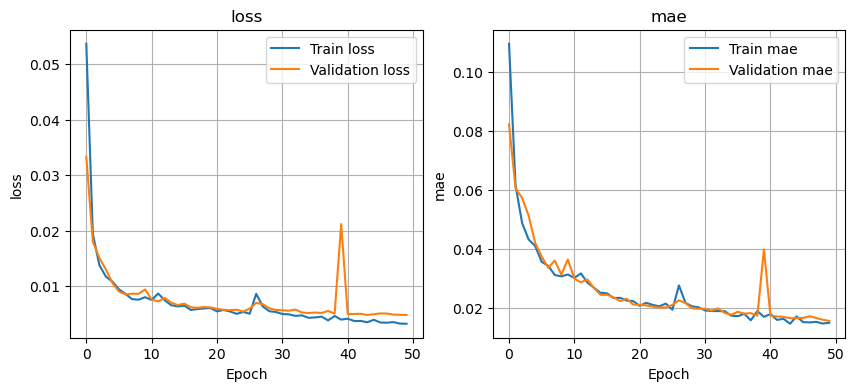

In [7]:
def plot_losses(history):
    history_keys = list(history.history.keys())
    plot_num = len(history_keys) // 2
    plt.figure(figsize=(5 * plot_num, 4))
    for i in range(plot_num):
        train_key = history_keys[i]
        val_key = history_keys[i + plot_num]
        plt.subplot(1, plot_num, i + 1)
        plt.plot(history.history[train_key], label=f'Train {train_key}')
        plt.plot(history.history[val_key], label=f'Validation {val_key[4:]}')
        plt.title(train_key)
        plt.xlabel('Epoch')
        plt.ylabel(train_key)
        plt.legend(loc='upper right')
        plt.grid(True)
    plt.show()

plot_losses(history)

## 5. Evaluate and save

Testing streams through the same spatial batcher. The trained model is fully convolutional, so the
graphs below can predict on the whole grid at once even though it was trained on patches.

In [8]:
def evaluate_test_set():
    #ds_test = ds_std.sel(time=slice(f'{train_year+train_range+val_range}-01-01',
                                    #f'{train_year+train_range+val_range+test_range}-01-01'))
    ds_test = ds_std.sel(time=slice(f'{train_year+train_range+val_range}-01-01',
                                    f'{train_year+train_range+val_range+test_range}-01-01')).load()

    test_batcher = make_xbatcher(ds_test, patch_dims)

    test_dataset = tf.data.Dataset.from_generator(
        mtg.make_tf_gen(test_batcher, X_vars), output_signature=output_signature
    ).batch(BATCH_SIZE)
    test_steps = (len(test_batcher) * DAY_BATCH) // BATCH_SIZE
    test_mse, test_mae = model.evaluate(test_dataset, steps=test_steps)
    print("Test MSE:", test_mse)
    print("Test MAE:", test_mae)
    return test_mse, test_mae

test_mse, test_mae = evaluate_test_set()

model_name = 'UNet_Spatial_mse'
folder_path = f'models/{zarr_label}'
os.makedirs(folder_path, exist_ok=True)
model.save(f'{folder_path}/{model_name}.keras')

300/300 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - loss: 0.0073 - mae: 0.0207
Test MSE: 0.007318116724491119
Test MAE: 0.020690832287073135


## 6. Visualizations

Same graphs as the original notebook. The model predicts on the whole cropped grid; `extent` is the full
IO box. If you ran with `FULL_GRID=False`, adjust `extent` to the Arab Sea box.

2026-07-07 02:19:12.251269: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 02:19:12.417971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


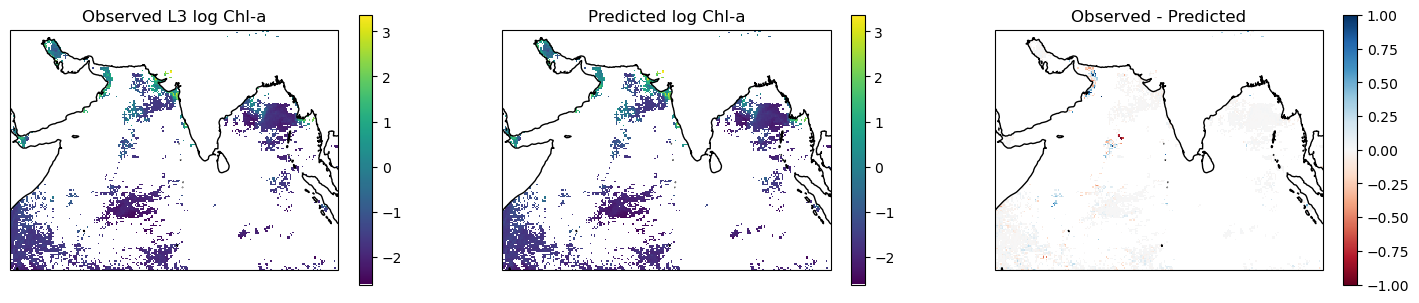

In [10]:
def plot_prediction_observed(zarr_raw, model, date_to_predict):
    target_date = pd.to_datetime(date_to_predict)
    X = np.stack([np.nan_to_num(ds_std[v].sel(time=target_date).values, nan=0.0) for v in X_vars],
                 axis=-1).astype(np.float32)
    predicted_CHL_std = model.predict(X[np.newaxis, ...], verbose=0)[0, :, :, 0]
    predicted_CHL = (predicted_CHL_std * y_std) + y_mean

    zarr_date = zarr_raw.sel(time=target_date)
    fake_cloud_flag = ds_std['fake_cloud_flag'].sel(time=target_date).values
    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(zarr_date['CHL_cmes-level3'].values)
    predicted_CHL = np.where(np.isnan(true_CHL), np.nan, predicted_CHL)
    diff = true_CHL - predicted_CHL

    vmax, vmin = np.nanmax((true_CHL, predicted_CHL)), np.nanmin((true_CHL, predicted_CHL))
    extent = [42, 101.75, -11.75, 32]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': ccrs.PlateCarree()})
    for ax, arr, ttl, cmap in [(axes[0], true_CHL, 'Observed L3 log Chl-a', None),
                               (axes[1], predicted_CHL, 'Predicted log Chl-a', None),
                               (axes[2], diff, 'Observed - Predicted', plt.cm.RdBu)]:
        vv = dict(vmin=-1, vmax=1, cmap=cmap) if cmap else dict(vmin=vmin, vmax=vmax)
        im = ax.imshow(arr, extent=extent, origin='upper', transform=ccrs.PlateCarree(),
                       interpolation='nearest', **vv)
        ax.add_feature(cfeature.COASTLINE)
        ax.set_title(ttl)
        fig.colorbar(im, ax=ax, shrink=0.7)
    plt.show()

#plot_prediction_observed(ds_cropped, model, '2020-09-08')
plot_prediction_observed(ds_cropped, model, f'{train_year+train_range+val_range}-09-08')


### Gapfill comparison

Instead of scoring against the gappy Level-3, this feeds the model the *dense* observed Level-3 as the
`masked_CHL` input and marks the real clouds as the gaps to fill, then compares the U-Net's gap-free
output against the Copernicus Level-4 gapfree product (the closest thing to truth).


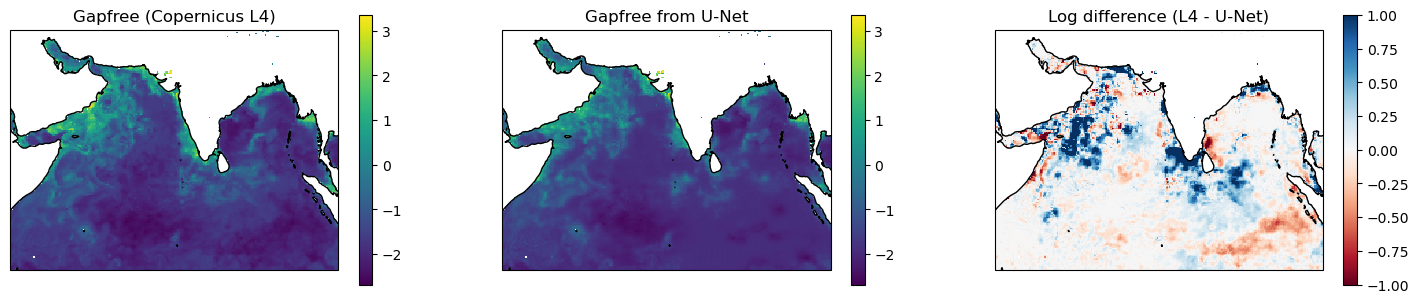

In [12]:
# CHL_cmes-gapfree (the L4 "truth") is not in IO_rechunked.zarr, so pull it from the original IO.zarr,
# cropped to the same full grid so it lines up with the prediction.
_orig = mtg.crop_to_multiple(
    xr.open_zarr(os.path.expanduser("~/shared/mind_the_chl_gap/IO.zarr"), chunks={}),
    multiple=8,
)

def plot_prediction_gapfill(zarr_raw, model, date_to_predict):
    target_date = pd.to_datetime(date_to_predict)
    zarr_date = zarr_raw.sel(time=target_date)
    m_mean, m_std = stats['masked_CHL'][0], stats['masked_CHL'][1]

    chans = {v: np.nan_to_num(ds_std[v].sel(time=target_date).values, nan=0.0) for v in X_vars}
    with np.errstate(divide='ignore', invalid='ignore'):
        obs = np.log(zarr_date['CHL_cmes-level3'].values)
    obs_std = np.nan_to_num((obs - m_mean) / m_std, nan=0.0, posinf=0.0, neginf=0.0)

    orig_fake = chans['fake_cloud_flag'].copy()
    orig_real = chans['real_cloud_flag'].copy()
    chans['masked_CHL']      = obs_std
    chans['fake_cloud_flag'] = orig_real
    chans['real_cloud_flag'] = np.zeros_like(orig_real)
    chans['valid_CHL_flag']  = np.where(orig_fake == 1, 1.0, chans['valid_CHL_flag'])

    X = np.stack([chans[v] for v in X_vars], axis=-1).astype(np.float32)
    predicted_CHL = model.predict(X[np.newaxis, ...], verbose=0)[0, :, :, 0] * y_std + y_mean

    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(_orig['CHL_cmes-gapfree'].sel(time=target_date).values)   # from original IO.zarr
    predicted_CHL = np.where(np.isnan(true_CHL), np.nan, predicted_CHL)
    log_diff = true_CHL - predicted_CHL

    vmin, vmax = np.nanmin((true_CHL, predicted_CHL)), np.nanmax((true_CHL, predicted_CHL))
    extent = [float(ds_cropped.lon.min()), float(ds_cropped.lon.max()),
              float(ds_cropped.lat.min()), float(ds_cropped.lat.max())]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': ccrs.PlateCarree()})
    for ax, arr, ttl, kw in [
        (axes[0], true_CHL,      'Gapfree (Copernicus L4)',      dict(vmin=vmin, vmax=vmax)),
        (axes[1], predicted_CHL, 'Gapfree from U-Net',           dict(vmin=vmin, vmax=vmax)),
        (axes[2], log_diff,      'Log difference (L4 - U-Net)',  dict(vmin=-1, vmax=1, cmap=plt.cm.RdBu)),
    ]:
        im = ax.imshow(arr, extent=extent, origin='upper', transform=ccrs.PlateCarree(),
                       interpolation='nearest', **kw)
        ax.add_feature(cfeature.COASTLINE)
        ax.set_title(ttl)
        fig.colorbar(im, ax=ax, shrink=0.7)
    plt.show()

plot_prediction_gapfill(ds_cropped, model, f'{train_year+train_range+val_range}-09-08')


---
## Next steps: xbatcher features to adopt

The full exploration is in `xbatcher_spatial_exploration.ipynb`. The two most relevant to plug into the
loop above:

- **Percent-ocean filtering** (below): skip patches that are mostly land or gap, so training does not
  waste effort on empty tiles.
- **Stitching**: reassemble per-patch predictions into a full map (the graphs above sidestep this by
  predicting the whole grid at once, which only works while the grid fits in one forward pass).

Also worth trying: xbatcher's `loaders.keras` in place of `make_tf_gen`, and the shuffling caveat from
Keenan's study (cache a *pool* of tiles and shuffle across it, do not drain one tile at a time).

In [ ]:
# Percent-ocean filtering: precompute valid patch indices to sample from (reimplements filter_fn).
def ocean_frac(patch, var='CHL_cmes-level3'):
    return float(np.isfinite(patch[var].values).mean())

_day = ds_cropped[['CHL_cmes-level3']].isel(time=0)
_bg2d = BatchGenerator(_day, input_dims={"lat": LAT_PATCH, "lon": LON_PATCH},
                       input_overlap={"lat": 0, "lon": 0})
_fracs = np.array([ocean_frac(_bg2d[i]) for i in range(len(_bg2d))])
_valid = np.where(_fracs >= 0.5)[0]
print(f"{len(_valid)}/{len(_bg2d)} patches are >= 50% ocean-with-data on day 0")